# Week 12 Revision: Responding to the July 28 Review

**Trigger-Agnostic Behavioral Trust for Backdoor-Resilient Federated GPS Spoofing Detection**

Group 1: Will Jedrzejczak, Cole Walther, Dilpreet Gill
IT 445 Capstone, Summer 2026 · Advisor: Dr. Khalid Hasan

---

This notebook is the code deliverable for the review response. It reproduces every
table and figure added or changed in the revision, organised by the reviewer comment
that prompted it.

**Two things worth knowing before reading.**

The revision found two claims in our previous draft that were **wrong**, not merely
imprecise:

1. We had blamed a weak detector on the dataset. Section 5 shows it is our federated
   configuration: the same architecture trained centrally reaches 0.907 recall against
   0.529 federated.
2. Our 1.1% overhead figure used a denominator that summed every client's training
   time. Section 7 recomputes it as 3.40% on a parallel round.

And the experiment the review called *"probably the single most valuable"* found a real
failure in our defense. Section 3 reports it: under uneven client data the behavioral
trust layer stops firing entirely.

All experiments run through one shared harness (`fl_common.py`, `fl_runner.py`) so no
two of them can disagree about the data split, the model, the attack or a metric.

## 0. Setup

`RUN_EXPERIMENTS` controls what this notebook does.

- `False` (default): load the exported CSVs and display everything. Seconds.
- `True`: re-execute every experiment through the harness. Several hours on CPU.

The CSVs in `results/` were produced by exactly the code the `True` path runs, so the
two modes agree by construction. Runs are deterministic given the fixed data seed; we
verified this by executing the FLTrust benchmark twice and getting bit-identical output.

In [1]:
RUN_EXPERIMENTS = False      # set True to recompute everything from scratch

import subprocess, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

HERE = Path.cwd()
RES = HERE / 'results'
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 60)


def show(csv, cols=None, caption=None):
    "Display an exported results table."
    df = pd.read_csv(RES / csv)
    if cols:
        df = df[cols]
    if caption:
        display(Markdown(f'**{caption}**'))
    display(df)
    return df


def fig(png, width=880):
    display(Image(filename=str(RES / png), width=width))


def run(script):
    "Execute an experiment script, streaming its output."
    if not RUN_EXPERIMENTS:
        print(f'[skipped] {script} - set RUN_EXPERIMENTS = True to execute')
        return
    print(f'[running] {script} ...')
    r = subprocess.run([sys.executable, '-u', script], cwd=HERE)
    print(f'[{"ok" if r.returncode == 0 else "FAILED"}] {script}')


print('mode:', 'RECOMPUTE' if RUN_EXPERIMENTS else 'load exported results')
print('results dir:', RES, '|', len(list(RES.glob('*.csv'))), 'CSVs present')

mode: load exported results
results dir: C:\Users\willi\uav-capstone\weeks\week12-paper\results | 13 CSVs present


### The shared harness

Everything below imports from two modules, so the setup is defined once.

- **`fl_common.py`** — the fixed preprocessing and split (seed 42), the probe
  construction, the model, IID and skewed partitioners, the CN0 poisoning attack, the
  nine aggregation rules, and one metric function.
- **`fl_runner.py`** — one federated run under any rule. Takes `n_attack` (the true
  number of compromised clients) separately from `assumed_f` (what the Byzantine-robust
  baselines are *told*), which is what makes Section 6 possible.

In [2]:
import fl_common as F
from fl_runner import ALL_RULES

print('features         :', F.FEATURES)
print('probe features   :', F.PROBE_FEATS, f'({len(F.PROBE_FEATS)} of {len(F.FEATURES)})')
print('model parameters :', F.n_params(F.BinaryDNN(F.D)))
print('client pool/root/test:', len(F.X_pool_sc), '/', len(F.X_root_sc), '/', len(F.X_test_sc))
print('aggregation rules:', ALL_RULES)
print('seeds            :', F.SEEDS, '| data seed fixed at', F.DATA_SEED)

features         : ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'PIP', 'PQP', 'TCD', 'CN0']
probe features   : ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'TCD', 'CN0'] (8 of 10)
model parameters : 3329
client pool/root/test: 114000 / 6000 / 30000
aggregation rules: ['fedavg', 'accweight', 'median', 'trimmed', 'krum', 'multikrum', 'fltrust', 'trust', 'full']
seeds            : [42, 7, 123] | data seed fixed at 42


---
## 1. Comments 1 and 5 — Comparison against published baselines

> *"Include direct baseline comparisons with at least: FLTrust, coordinate-wise median,
> trimmed mean, Krum or Multi-Krum, server-validated accuracy weighting."*

All five, plus FedAvg, implemented and run on the identical split, attack, seeds and
metrics. Nothing is quoted from another paper.

**FLTrust** follows Cao et al. (NDSS 2021) as described in the paper the advisor
attached: the server trains the current global model on its own root set to get an
update $g_0$, scores each client by $\mathrm{TS}_i = \mathrm{ReLU}(\cos(g_i, g_0))$, and
rescales every client update to $\lVert g_0 \rVert$ before a trust-weighted mean.

In [3]:
run('exp_baselines.py')

[skipped] exp_baselines.py - set RUN_EXPERIMENTS = True to execute


**All nine aggregation rules, identical pipeline (mean +/- std over 3 seeds)**

,Method,Clean Accuracy,Spoofing Recall,BSR,Backdoor Lift,Attacker Detect,Honest False-Flag,Server ms/round
0,Honest FedAvg (no attack),0.7112 +/- 0.0019,0.5292 +/- 0.0115,0.6367 +/- 0.0141,+0.0000 +/- 0.0000,---,---,1.0 +/- 0.0
1,FedAvg,0.6932 +/- 0.0032,0.3641 +/- 0.0096,0.8782 +/- 0.0178,+0.2415 +/- 0.0048,---,---,1.0 +/- 0.0
2,Accuracy-weighted FedAvg,0.6897 +/- 0.0046,0.3524 +/- 0.0148,0.9402 +/- 0.0096,+0.3036 +/- 0.0124,0.0%,0.0%,1.3 +/- 0.0
3,Coordinate-wise median,0.7101 +/- 0.0035,0.5008 +/- 0.0133,0.7013 +/- 0.0072,+0.0646 +/- 0.0074,---,---,0.9 +/- 0.0
4,Trimmed mean,0.7061 +/- 0.0021,0.4808 +/- 0.0121,0.7154 +/- 0.0099,+0.0787 +/- 0.0065,---,---,1.4 +/- 0.0
5,Krum,0.7071 +/- 0.0019,0.5168 +/- 0.0116,0.6698 +/- 0.0165,+0.0331 +/- 0.0035,100.0%,---,1.4 +/- 0.1
6,Multi-Krum,0.7108 +/- 0.0021,0.5282 +/- 0.0165,0.6428 +/- 0.0102,+0.0061 +/- 0.0041,100.0%,---,1.4 +/- 0.0
7,FLTrust,0.6962 +/- 0.0009,0.4687 +/- 0.0178,0.7154 +/- 0.0141,+0.0787 +/- 0.0176,84.7%,0.0%,204.4 +/- 0.3
8,Behavioral trust (ours),0.7112 +/- 0.0017,0.5307 +/- 0.0140,0.6406 +/- 0.0102,+0.0039 +/- 0.0047,100.0%,0.3%,38.0 +/- 0.3
9,"Trust + median (ours, D2)",0.7143 +/- 0.0025,0.5560 +/- 0.0194,0.6101 +/- 0.0313,-0.0265 +/- 0.0174,100.0%,0.3%,38.6 +/- 0.9


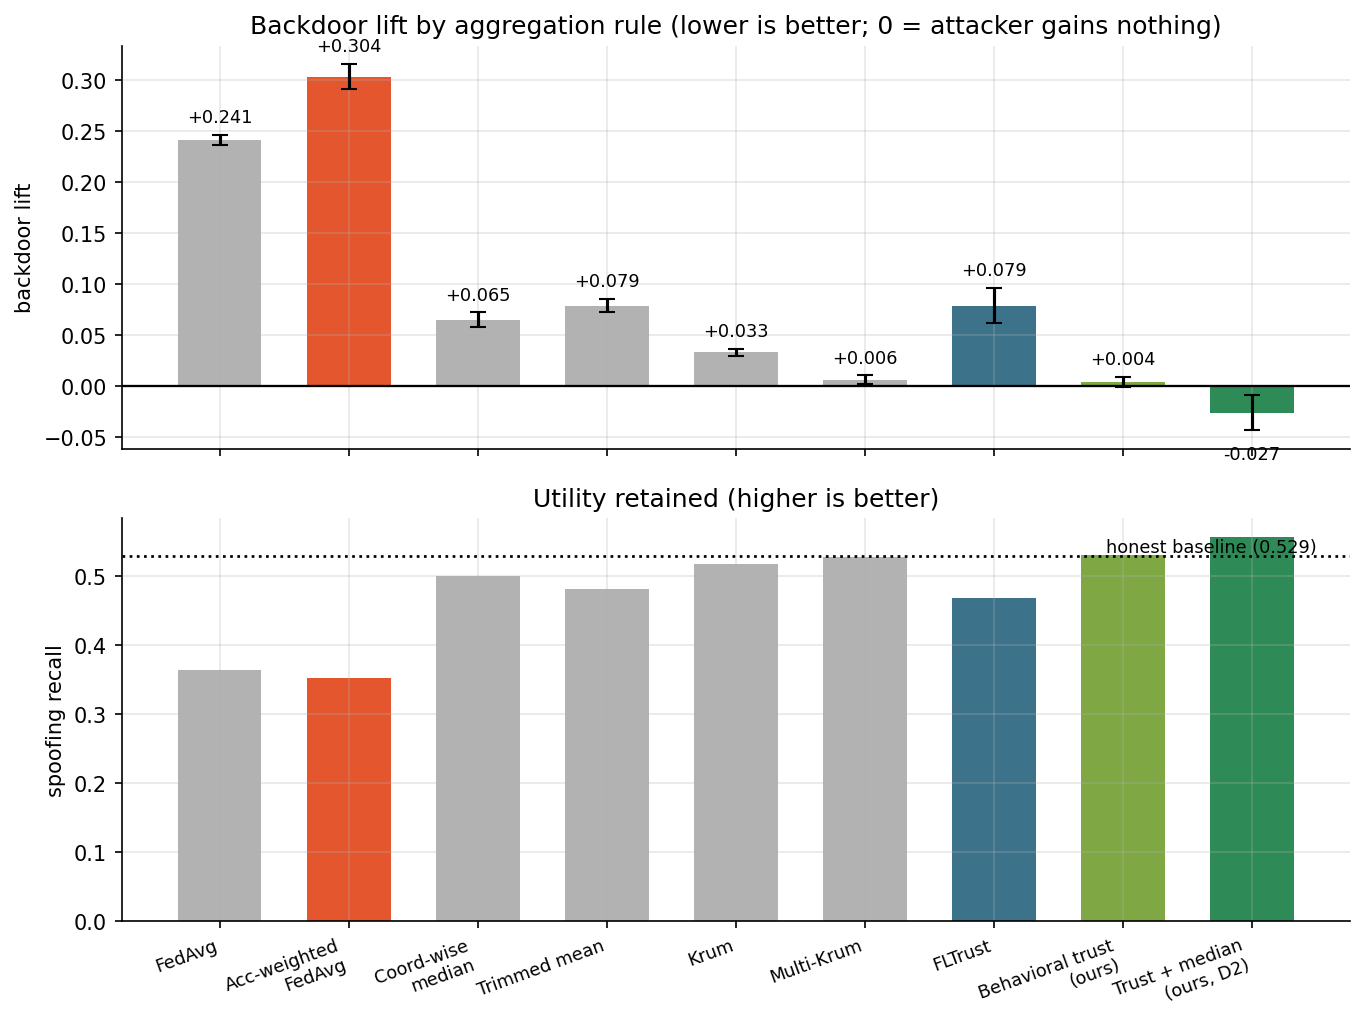

In [4]:
b = show('baseline_comparison.csv',
         ['Method', 'Clean Accuracy', 'Spoofing Recall', 'BSR', 'Backdoor Lift',
          'Attacker Detect', 'Honest False-Flag', 'Server ms/round'],
         'All nine aggregation rules, identical pipeline (mean +/- std over 3 seeds)')
fig('fig_baselines.png')

**The result that does not favour us, reported rather than omitted.**

Multi-Krum reaches **+0.0061** lift against our behavioral trust at **+0.0039**. At three
seeds those are statistically indistinguishable, and Multi-Krum is ~27x cheaper on server
time. We therefore removed any claim that a behavioral probe is *necessary* to stop this
attack in this setting, because this table would contradict it.

What survives as a genuine distinction is tested in Section 6: the Byzantine-robust rules
must be told how many clients are compromised, and we must not.

FLTrust removes about two-thirds of the attack (+0.0787) but leaves a clear residual, and
its clean accuracy and recall fall *below* the honest baseline because rescaling every
update to the server norm throttles honest clients too. It is also the most expensive rule
tested at 204 ms/round, since it trains a server model every round.

---
## 2. Comment 2 — Non-IID client data

> *"This is probably the single most valuable additional experiment for improving our
> paper's acceptance chances."*

It was, and it found a failure in our defense.

### 2.1 The requested partitioning did not produce a usable experiment

We first ran Dirichlet partitioning at $\alpha \in \{0.1, 0.5, 1.0\}$ exactly as asked.
Dirichlet mass concentrates, so most clients end up holding a single class. The federated
detector then never learns the spoofed class at all and the *honest* baseline collapses,
which leaves backdoor lift with no headroom to measure. At $\alpha = 0.1$ one compromised
client drew **zero** spoofed rows and could not mount the attack.

This run is kept as a negative result rather than used to rank defenses.

In [5]:
show('noniid_unconstrained_collapse.csv',
     ['Condition', 'Method', 'Spoofing Recall', 'BSR', 'Backdoor Lift'],
     'Unconstrained Dirichlet: the honest baseline itself collapses (negative result)')
display(Markdown('Note the honest rows: recall falls to **0.0737** at a=0.5 and '
                 '**0.0011** at a=0.1, with BSR saturating at 1.000. '
                 'Lift is measured against that baseline, so nothing can be measured.'))
show('noniid_unconstrained_profile.csv', caption='Realised partitions, showing why')

**Unconstrained Dirichlet: the honest baseline itself collapses (negative result)**

,Condition,Method,Spoofing Recall,BSR,Backdoor Lift
0,IID,Honest FedAvg (no attack),0.5292 +/- 0.0115,0.6367 +/- 0.0141,+0.0000 +/- 0.0000
1,IID,FedAvg,0.3641 +/- 0.0096,0.8782 +/- 0.0178,+0.2415 +/- 0.0048
2,IID,Acc-weighted FedAvg,0.3524 +/- 0.0148,0.9402 +/- 0.0096,+0.3036 +/- 0.0124
3,IID,Coordinate-wise median,0.5008 +/- 0.0133,0.7013 +/- 0.0072,+0.0646 +/- 0.0074
4,IID,FLTrust,0.4687 +/- 0.0178,0.7154 +/- 0.0141,+0.0787 +/- 0.0176
5,IID,Behavioral trust (ours),0.5307 +/- 0.0140,0.6406 +/- 0.0102,+0.0039 +/- 0.0047
6,IID,Trust + median (ours),0.5560 +/- 0.0194,0.6101 +/- 0.0313,-0.0265 +/- 0.0174
7,Dirichlet a=1.0,Honest FedAvg (no attack),0.4871 +/- 0.0776,0.7199 +/- 0.0667,+0.0000 +/- 0.0000
8,Dirichlet a=1.0,FedAvg,0.2663 +/- 0.1193,0.9780 +/- 0.0278,+0.2581 +/- 0.0410
9,Dirichlet a=1.0,Acc-weighted FedAvg,0.2289 +/- 0.1181,0.9942 +/- 0.0081,+0.2742 +/- 0.0592


Note the honest rows: recall falls to **0.0737** at a=0.5 and **0.0011** at a=0.1, with BSR saturating at 1.000. Lift is measured against that baseline, so nothing can be measured.

**Realised partitions, showing why**

,Condition,Seed,Min rows,Max rows,Spoof frac min,Spoof frac max,Attacker spoofed rows
0,IID,42,9690,9690,0.400,0.400,"[3876, 3876]"
1,IID,7,9690,9690,0.400,0.400,"[3876, 3876]"
2,IID,123,9690,9690,0.400,0.400,"[3876, 3876]"
3,Dirichlet a=1.0,42,3751,15334,0.009,0.932,"[277, 4140]"
4,Dirichlet a=1.0,7,1774,30305,0.001,0.917,"[7233, 1812]"
5,Dirichlet a=1.0,123,542,31929,0.149,0.817,"[1680, 2843]"
6,Dirichlet a=0.5,42,2193,22374,0.008,0.912,"[18, 5167]"
7,Dirichlet a=0.5,7,604,31331,0.001,0.933,"[127, 6279]"
8,Dirichlet a=0.5,123,833,23848,0.000,0.999,"[4666, 1961]"
9,Dirichlet a=0.1,42,605,30235,0.000,1.000,"[76, 1791]"


,Condition,Seed,Min rows,Max rows,Spoof frac min,Spoof frac max,Attacker spoofed rows
0,IID,42,9690,9690,0.400,0.400,"[3876, 3876]"
1,IID,7,9690,9690,0.400,0.400,"[3876, 3876]"
2,IID,123,9690,9690,0.400,0.400,"[3876, 3876]"
3,Dirichlet a=1.0,42,3751,15334,0.009,0.932,"[277, 4140]"
4,Dirichlet a=1.0,7,1774,30305,0.001,0.917,"[7233, 1812]"
5,Dirichlet a=1.0,123,542,31929,0.149,0.817,"[1680, 2843]"
6,Dirichlet a=0.5,42,2193,22374,0.008,0.912,"[18, 5167]"
7,Dirichlet a=0.5,7,604,31331,0.001,0.933,"[127, 6279]"
8,Dirichlet a=0.5,123,833,23848,0.000,0.999,"[4666, 1961]"
9,Dirichlet a=0.1,42,605,30235,0.000,1.000,"[76, 1791]"


### 2.2 The partitioning we used instead

The review's **second** listed option: *unequal benign/spoofed class ratios across
clients*. Every client keeps an equal number of rows but a different class ratio, drawn
from $\mathrm{Dir}(\alpha)$ and clipped so both classes remain present. Smaller $\alpha$
widens the spread around the global 0.40.

We validated that the honest detector survives each level **before** running the
comparison, which is the check the first attempt failed.

In [6]:
for a in (10.0, 3.0):
    cl = F.ratio_skew_split(42, a)
    d = F.describe_split(cl)
    print(f'alpha={a:>5}: spoofed fraction {min(d["spoof_frac"]):.3f} - {max(d["spoof_frac"]):.3f}'
          f'  | rows {min(d["rows"])}-{max(d["rows"])}'
          f'  | attacker spoofed rows {d["atk_spoof_rows"]}')
print('\nIID reference: every client at 0.400 spoofed, 9690 rows')

alpha= 10.0: spoofed fraction 0.277 - 0.594  | rows 9690-9690  | attacker spoofed rows [4363, 3333]
alpha=  3.0: spoofed fraction 0.191 - 0.722  | rows 9621-9666  | attacker spoofed rows [4644, 2823]

IID reference: every client at 0.400 spoofed, 9690 rows


In [7]:
run('exp_noniid.py')

[skipped] exp_noniid.py - set RUN_EXPERIMENTS = True to execute


**Non-IID sweep, reporting all seven quantities the review requested**

,Condition,Method,Clean Accuracy,Spoofing Recall,BSR,Backdoor Lift,Attacker Detect,Honest False-Flag,Attacker Trust,Honest Trust
0,IID,Honest FedAvg (no attack),0.7112 +/- 0.0019,0.5292 +/- 0.0115,0.6367 +/- 0.0141,+0.0000 +/- 0.0000,---,---,---,---
1,IID,FedAvg,0.6932 +/- 0.0032,0.3641 +/- 0.0096,0.8782 +/- 0.0178,+0.2415 +/- 0.0048,---,---,---,---
2,IID,Acc-weighted FedAvg,0.6897 +/- 0.0046,0.3524 +/- 0.0148,0.9402 +/- 0.0096,+0.3036 +/- 0.0124,0.0%,0.0%,0.1356 +/- 0.0009,0.0911 +/- 0.0002
3,IID,Coordinate-wise median,0.7101 +/- 0.0035,0.5008 +/- 0.0133,0.7013 +/- 0.0072,+0.0646 +/- 0.0074,---,---,---,---
4,IID,FLTrust,0.6962 +/- 0.0009,0.4687 +/- 0.0178,0.7154 +/- 0.0141,+0.0787 +/- 0.0176,84.7%,0.0%,0.0390 +/- 0.0009,0.1152 +/- 0.0002
5,IID,Behavioral trust (ours),0.7112 +/- 0.0017,0.5307 +/- 0.0140,0.6406 +/- 0.0102,+0.0039 +/- 0.0047,100.0%,0.3%,0.0001 +/- 0.0001,0.1250 +/- 0.0000
6,IID,Trust + median (ours),0.7143 +/- 0.0025,0.5560 +/- 0.0194,0.6101 +/- 0.0313,-0.0265 +/- 0.0174,100.0%,0.3%,0.0001 +/- 0.0001,0.1250 +/- 0.0000
7,Ratio skew a=10 (mild),Honest FedAvg (no attack),0.6998 +/- 0.0017,0.4937 +/- 0.0091,0.6788 +/- 0.0098,+0.0000 +/- 0.0000,---,---,---,---
8,Ratio skew a=10 (mild),FedAvg,0.6868 +/- 0.0044,0.3461 +/- 0.0125,0.9370 +/- 0.0254,+0.2583 +/- 0.0337,---,---,---,---
9,Ratio skew a=10 (mild),Acc-weighted FedAvg,0.6807 +/- 0.0038,0.3153 +/- 0.0172,0.9779 +/- 0.0030,+0.2991 +/- 0.0109,0.0%,0.0%,0.1313 +/- 0.0008,0.0922 +/- 0.0002


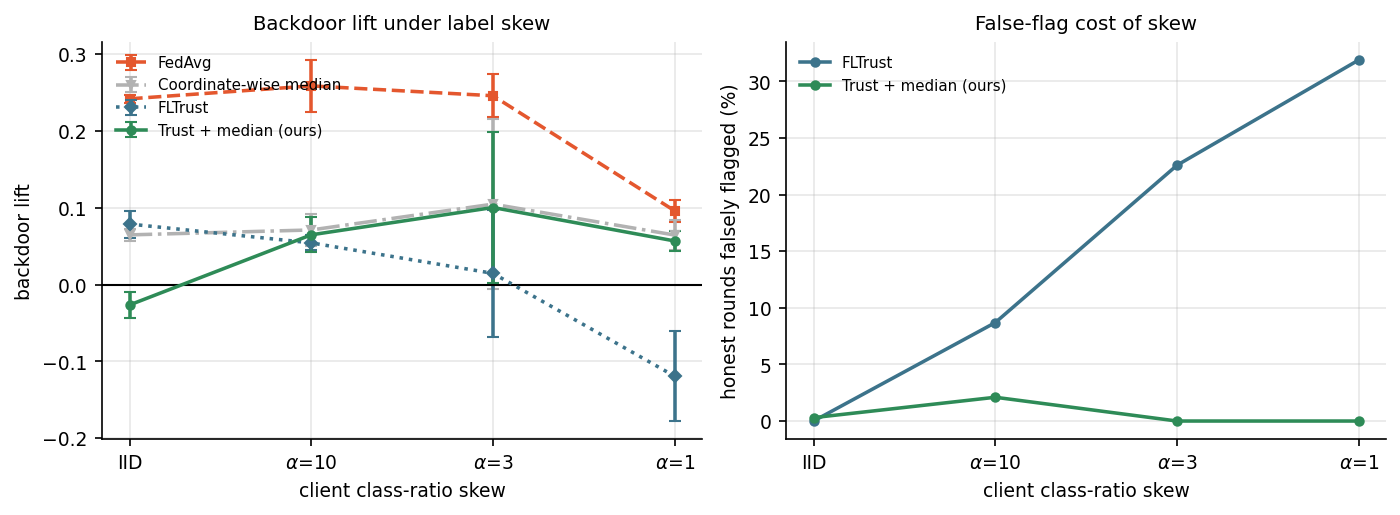

In [8]:
n = show('noniid_dirichlet.csv',
         ['Condition', 'Method', 'Clean Accuracy', 'Spoofing Recall', 'BSR', 'Backdoor Lift',
          'Attacker Detect', 'Honest False-Flag', 'Attacker Trust', 'Honest Trust'],
         'Non-IID sweep, reporting all seven quantities the review requested')
fig('fig_noniid.png')

### 2.3 The finding

**The behavioral trust layer does not survive label skew.**

| | Evenly split | Mild skew | Moderate skew |
|---|---|---|---|
| Attacker trust (fair share 0.100) | **0.0001** | 0.0942 | 0.1023 |
| Compromised clients detected | **100%** | 8.3% | **0%** |
| Lift, trust layer alone | +0.0039 | **+0.2374** | **+0.2482** |
| Lift, full defense | −0.0265 | +0.0647 | +0.1002 |
| Lift, no defense at all | +0.2415 | +0.2583 | +0.2455 |

Trust-only under skew is statistically indistinguishable from having no defense. The full
defense holds up better, but its numbers track coordinate-wise median alone
(+0.0710, +0.1046) almost exactly, which means **the median layer is carrying it**.

> **Read the honest false-flag column carefully.** The 0.0% at moderate skew is *not* an
> improvement. The gate has stopped firing at all, so it flags nobody, attacker or honest
> client alike.

### 2.4 Why, tested rather than asserted

Suspicion is a deficit below the cohort median measured in cohort-MAD units. Under IID the
honest cohort is tight, so a backdoored client's deficit spans many MADs and clears the
dead-zone easily. Under skew honest clients legitimately disagree, the MAD inflates, and
the same absolute deficit becomes a fraction of one MAD. The attacker hides inside the
honest cohort's own variance.

If that diagnosis is right, lowering the dead-zone should partially recover detection.

In [9]:
run('exp_noniid_diagnosis.py')

[skipped] exp_noniid_diagnosis.py - set RUN_EXPERIMENTS = True to execute


**Dead-zone sweep: is this a threshold problem?**

,Condition,Dead-zone tau,Backdoor Lift,Attacker Trust,Attacker Detect,Honest False-Flag,Spoofing Recall
0,IID,0.5,-0.0122 +/- 0.0114,0.0000 +/- 0.0000,100.0%,6.3%,0.5420 +/- 0.0112
1,IID,1.0,-0.0212 +/- 0.0294,0.0000 +/- 0.0000,100.0%,4.9%,0.5534 +/- 0.0273
2,IID,2.0,-0.0265 +/- 0.0174,0.0001 +/- 0.0001,100.0%,0.3%,0.5560 +/- 0.0194
3,Ratio skew a=10,0.5,+0.0457 +/- 0.0425,0.0598 +/- 0.0049,38.9%,11.8%,0.4876 +/- 0.0365
4,Ratio skew a=10,1.0,+0.0470 +/- 0.0329,0.0811 +/- 0.0027,26.4%,6.9%,0.4737 +/- 0.0249
5,Ratio skew a=10,2.0,+0.0647 +/- 0.0228,0.0942 +/- 0.0044,8.3%,2.1%,0.4555 +/- 0.0150
6,Ratio skew a=3,0.5,+0.0851 +/- 0.1120,0.0886 +/- 0.0059,15.3%,7.6%,0.3797 +/- 0.0708
7,Ratio skew a=3,1.0,+0.0902 +/- 0.1024,0.0982 +/- 0.0041,1.4%,1.7%,0.3738 +/- 0.0650
8,Ratio skew a=3,2.0,+0.1002 +/- 0.0982,0.1023 +/- 0.0020,0.0%,0.0%,0.3618 +/- 0.0562


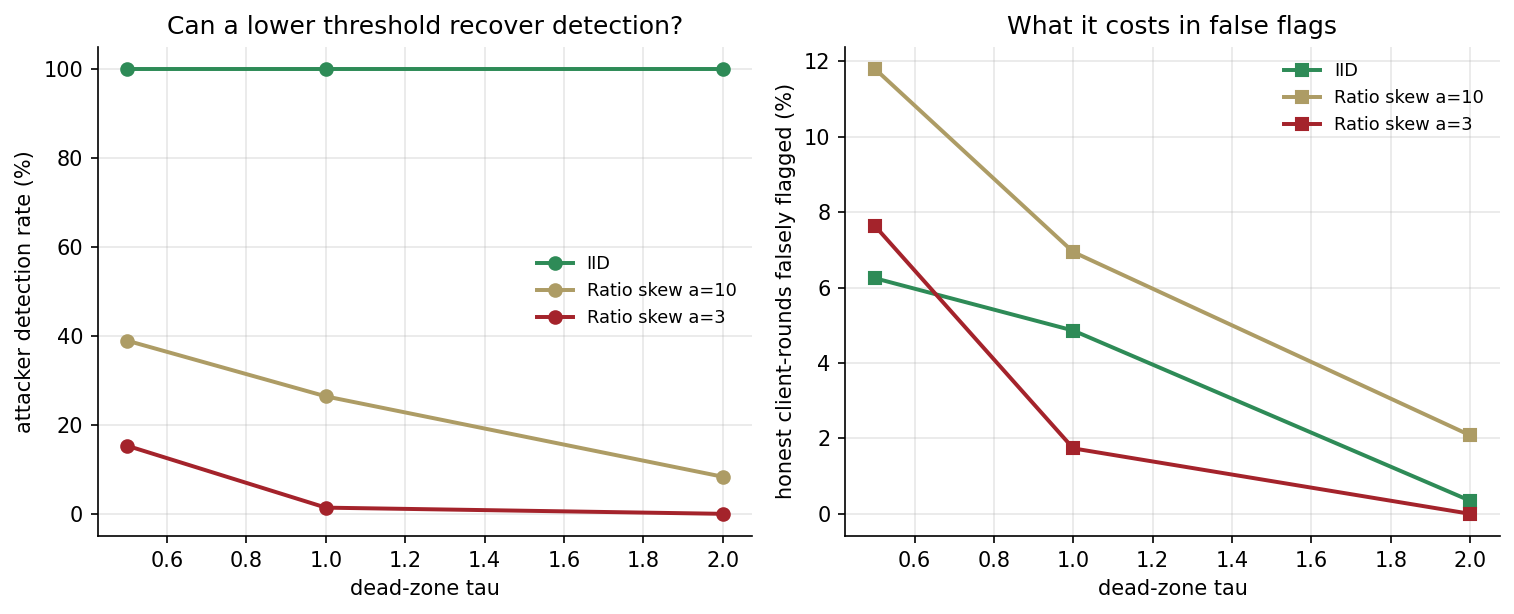

In [10]:
show('noniid_tau_diagnosis.csv', caption='Dead-zone sweep: is this a threshold problem?')
fig('fig_noniid_tau.png', width=820)

Detection partially recovers (8.3% → 38.9% at mild skew), which **confirms the mechanism**.
But it never approaches the IID figure and it costs 6–12% of honest client-rounds in false
flags, and under IID the same change is pure loss. So the limitation is the robust scaling
itself, not the threshold value. The fix would be a suspicion statistic normalised per
client rather than against a global cohort spread; that is untested and is the clearest
next step this work leaves open.

---
## 3. Comment 3 — The two-layer claim

> *"Revise the claim to: behavioral trust provides most of the observed protection ...
> while coordinate-wise median is retained as a robust aggregation backstop."*

Accepted and applied. Trust-only (+0.0039) and the full defense (−0.0265) are not
separated at three seeds, so the previous claim was not supported.

The review then asked for the right experiment: degrade the trust score until it is
imperfect and check whether the median limits the damage.

In [11]:
run('exp_median_stress.py')

[skipped] exp_median_stress.py - set RUN_EXPERIMENTS = True to execute


**Five ways to degrade trust scoring**

,Condition,Undefended Lift,Trust-only Lift,Full (trust+median) Lift,Median benefit (trust-only minus full),Attacker Trust,Attacker Detect,Honest False-Flag
0,"baseline (D2, IID)",+0.2415 +/- 0.0048,+0.0039 +/- 0.0047,-0.0265 +/- 0.0174,+0.0305 +/- 0.0219,0.0001 +/- 0.0001,100.0%,0.3%
1,"root 6,000 -> 600",+0.2415 +/- 0.0048,+0.0041 +/- 0.0052,-0.0276 +/- 0.0205,+0.0317 +/- 0.0256,0.0001 +/- 0.0001,100.0%,1.0%
2,30% root labels flipped,+0.2415 +/- 0.0048,+0.0032 +/- 0.0067,-0.0137 +/- 0.0208,+0.0169 +/- 0.0240,0.0167 +/- 0.0117,83.3%,0.7%
3,scaling 3 -> 10,-0.5888 +/- 0.0462,+0.0064 +/- 0.0063,-0.0266 +/- 0.0166,+0.0330 +/- 0.0227,0.0001 +/- 0.0001,100.0%,0.3%
4,non-IID Dirichlet a=0.5,+0.0426 +/- 0.0603,+0.0427 +/- 0.0603,+0.0380 +/- 0.0538,+0.0046 +/- 0.0066,0.1063 +/- 0.0033,0.0%,0.0%
5,dead-zone tau 2 -> 6,+0.2415 +/- 0.0048,+0.0089 +/- 0.0082,-0.0121 +/- 0.0175,+0.0210 +/- 0.0219,0.0037 +/- 0.0044,97.2%,0.3%


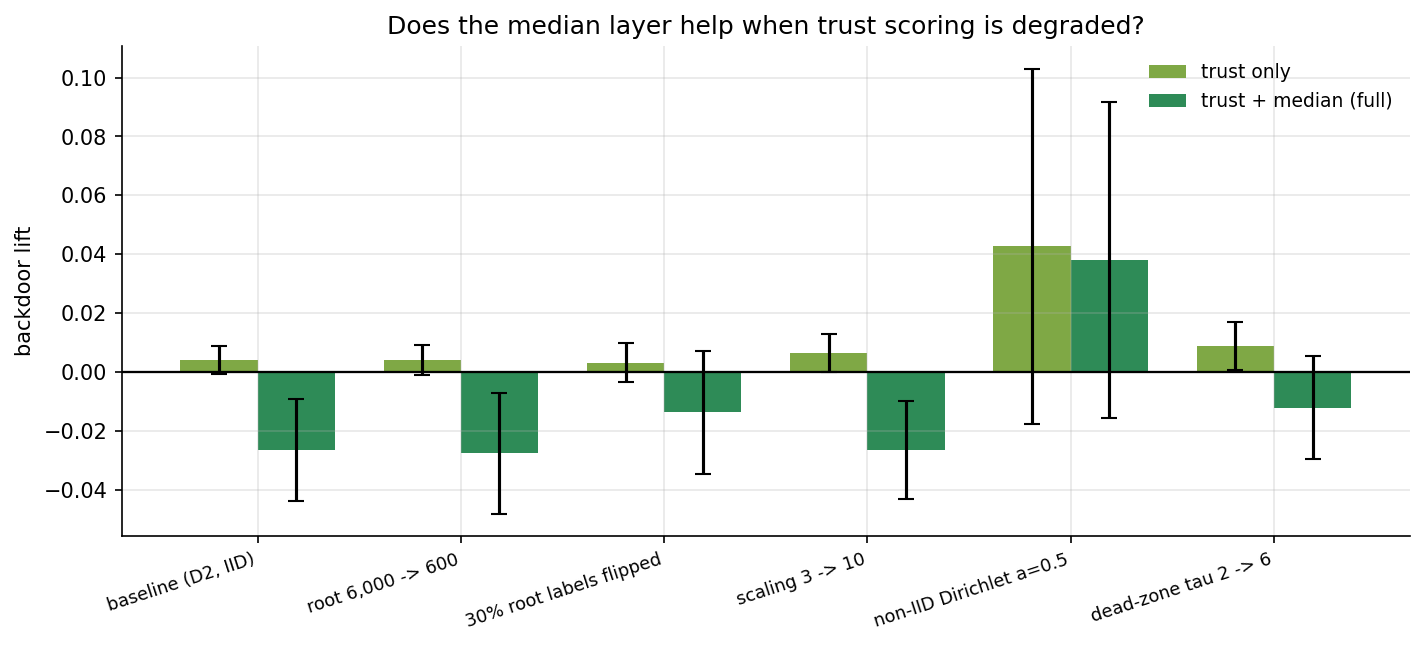

In [12]:
show('median_necessity.csv', caption='Five ways to degrade trust scoring')
fig('fig_median_necessity.png', width=820)

Under mild degradation the median contributes +0.017 to +0.033, the same size as the seed
spread, so we do not claim it as individually resolved there. **The decisive case is the
one the reviewer predicted:** under the label skew of Section 2, trust-only leaves +0.2374
and +0.2482 while the full defense leaves +0.0647 and +0.1002. The median removes **0.173**
and **0.148** of lift, an order of magnitude more than under IID.

One condition did not behave as intended and is reported as such: raising model-replacement
scaling from γ=3 to γ=10 **weakens** the attack (undefended lift −0.5888), because an update
scaled that hard destroys the global model rather than steering it.

---
## 4. Comment 4 — The base detector

> *"Do not claim that the system is secure simply because backdoor lift reaches zero."*

Two separate things were needed: separate the claims, and find out whether a stronger
classifier is even available.

### 4.1 The centralized ceiling

Several models trained on the entire 114,000-row pool with no federation, no attack and no
privacy constraint. This upper-bounds anything the federated system could reach.

In [13]:
run('exp_detector.py')

[skipped] exp_detector.py - set RUN_EXPERIMENTS = True to execute


**Centralized ceiling. Final row is the federated detector used in the paper.**

,Model,Clean Accuracy,Spoofing Recall,Precision,F1,Balanced Acc,False Alarm Rate,TP,FN,FP,TN,Triggered BSR
0,MLP 64-32-16 (paper model),0.8728,0.9073,0.8011,0.8509,0.8786,0.1502,10888,1112,2704,15296,0.3779
1,MLP 256-128-64 (wider),0.9192,0.9506,0.8617,0.9040,0.9244,0.1017,11407,593,1831,16169,0.3488
2,MLP 512-256-128-64 (deeper),0.9245,0.9742,0.8567,0.9117,0.9328,0.1087,11691,309,1956,16044,0.3331
3,Logistic regression,0.6094,0.2241,0.5277,0.3146,0.5452,0.1337,2689,9311,2407,15593,0.9394
4,Random forest (400 trees),0.9503,0.9595,0.9198,0.9392,0.9519,0.0558,11514,486,1004,16996,0.1037
5,Hist gradient boosting,0.9615,0.9929,0.9176,0.9538,0.9667,0.0594,11915,85,1070,16930,0.1213
6,Federated honest FedAvg (paper baseline),0.7112,0.5292,0.6782,0.5944,0.6809,0.1675,6350,5649,3014,14985,0.6367


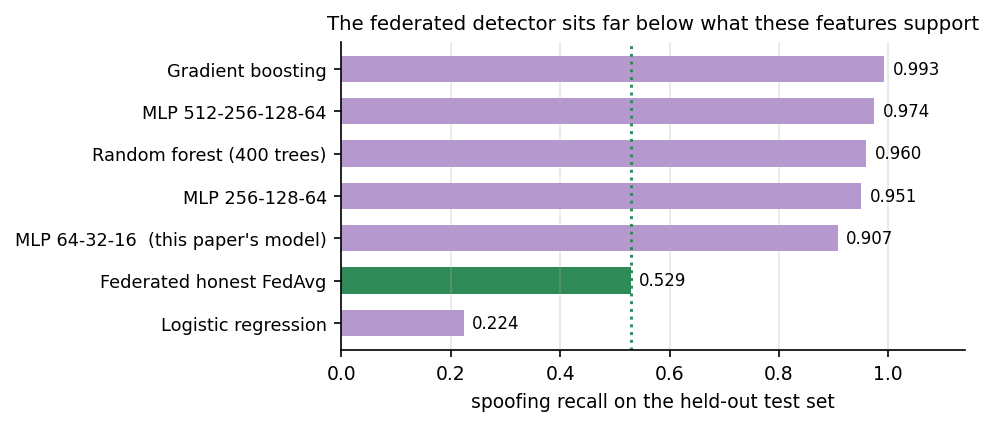

In [14]:
show('detector_ceiling.csv',
     ['Model', 'Clean Accuracy', 'Spoofing Recall', 'Precision', 'F1',
      'Balanced Acc', 'False Alarm Rate', 'TP', 'FN', 'FP', 'TN', 'Triggered BSR'],
     'Centralized ceiling. Final row is the federated detector used in the paper.')
fig('fig_detector_ceiling.png', width=760)

**This corrects our previous draft.** We had attributed the weak detector to limited
separability in the feature set. That is wrong. The *same* architecture reaches **0.9073**
recall trained centrally, and gradient boosting reaches **0.9929**, against **0.5292**
federated. The features are separable; twelve rounds of three local epochs on a small MLP
underfits.

A short search confirms a stronger federated configuration is reachable (30 rounds with
256-128-64 gives 0.851 honest recall). We did **not** re-run the full evaluation there, so
we make no claim that the defense conclusions transfer to it.

### 4.2 The claims, now separated

- **Supported:** the defense removes the attacker-induced *increase* in BSR.
- **Not supported, and not claimed:** that the detector reliably catches triggered
  spoofing. At our operating point an honest model already lets **63.7%** of
  trigger-bearing samples through, so driving lift to zero restores that baseline rather
  than making the system safe.

Raw BSR now appears beside lift in every table, and the full operating point is reported.

In [15]:
b = pd.read_csv(RES / 'baseline_comparison.csv')
display(Markdown('**Full operating point (from `baseline_comparison.csv`)**'))
display(b[['Method', 'Precision', 'Spoofing Recall', 'F1', 'Balanced Acc',
           'False Alarm', 'BSR', 'Backdoor Lift']])

**Full operating point (from `baseline_comparison.csv`)**

,Method,Precision,Spoofing Recall,F1,Balanced Acc,False Alarm,BSR,Backdoor Lift
0,Honest FedAvg (no attack),0.6782 +/- 0.0042,0.5292 +/- 0.0115,0.5944 +/- 0.0064,0.6809 +/- 0.0032,0.1675 +/- 0.0062,0.6367 +/- 0.0141,+0.0000 +/- 0.0000
1,FedAvg,0.7352 +/- 0.0061,0.3641 +/- 0.0096,0.4869 +/- 0.0089,0.6383 +/- 0.0041,0.0874 +/- 0.0033,0.8782 +/- 0.0178,+0.2415 +/- 0.0048
2,Accuracy-weighted FedAvg,0.7335 +/- 0.0059,0.3524 +/- 0.0148,0.4759 +/- 0.0140,0.6335 +/- 0.0062,0.0854 +/- 0.0035,0.9402 +/- 0.0096,+0.3036 +/- 0.0124
3,Coordinate-wise median,0.6894 +/- 0.0024,0.5008 +/- 0.0133,0.5800 +/- 0.0094,0.6752 +/- 0.0051,0.1504 +/- 0.0037,0.7013 +/- 0.0072,+0.0646 +/- 0.0074
4,Trimmed mean,0.6906 +/- 0.0014,0.4808 +/- 0.0121,0.5668 +/- 0.0080,0.6686 +/- 0.0038,0.1436 +/- 0.0045,0.7154 +/- 0.0099,+0.0787 +/- 0.0065
5,Krum,0.6750 +/- 0.0069,0.5168 +/- 0.0116,0.5852 +/- 0.0056,0.6754 +/- 0.0024,0.1660 +/- 0.0085,0.6698 +/- 0.0165,+0.0331 +/- 0.0035
6,Multi-Krum,0.6778 +/- 0.0031,0.5282 +/- 0.0165,0.5935 +/- 0.0094,0.6804 +/- 0.0045,0.1674 +/- 0.0075,0.6428 +/- 0.0102,+0.0061 +/- 0.0041
7,FLTrust,0.6730 +/- 0.0100,0.4687 +/- 0.0178,0.5522 +/- 0.0094,0.6583 +/- 0.0029,0.1522 +/- 0.0124,0.7154 +/- 0.0141,+0.0787 +/- 0.0176
8,Behavioral trust (ours),0.6775 +/- 0.0032,0.5307 +/- 0.0140,0.5951 +/- 0.0078,0.6811 +/- 0.0037,0.1685 +/- 0.0067,0.6406 +/- 0.0102,+0.0039 +/- 0.0047
9,"Trust + median (ours, D2)",0.6732 +/- 0.0088,0.5560 +/- 0.0194,0.6087 +/- 0.0089,0.6879 +/- 0.0041,0.1803 +/- 0.0131,0.6101 +/- 0.0313,-0.0265 +/- 0.0174


---
## 5. Comment 6 — Overhead, recomputed

> *"The denominator looks like to come from a sequential simulation ... Do not claim
> large-fleet scalability without testing it."*

Both points were correct.

In [16]:
run('exp_overhead.py')

[skipped] exp_overhead.py - set RUN_EXPERIMENTS = True to execute


**Both denominators**

,Defense,Server overhead (ms/round),Sequential round (ms),Overhead vs sequential,Parallel round (ms),Overhead vs parallel
0,Behavioral trust + median (ours),34.0,3449,0.98%,999,3.40%
1,FLTrust,168.3,3449,4.88%,999,16.86%


**Scaling in clients, root-set size and probe count**

,Axis,Setting,Server ms/round,FLTrust ms/round,Overhead vs parallel
0,clients,5,19.3,182.6,5.55%
1,clients,10,34.0,172.5,9.55%
2,clients,20,69.5,167.5,17.96%
3,clients,40,139.1,183.2,34.89%
4,root rows,600,25.5,22.4,6.19%
5,root rows,1500,36.8,53.0,9.71%
6,root rows,3000,30.6,91.1,8.00%
7,root rows,6000,37.1,183.2,10.29%
8,probe features,2,13.2,---,3.53%
9,probe features,4,19.9,---,5.55%


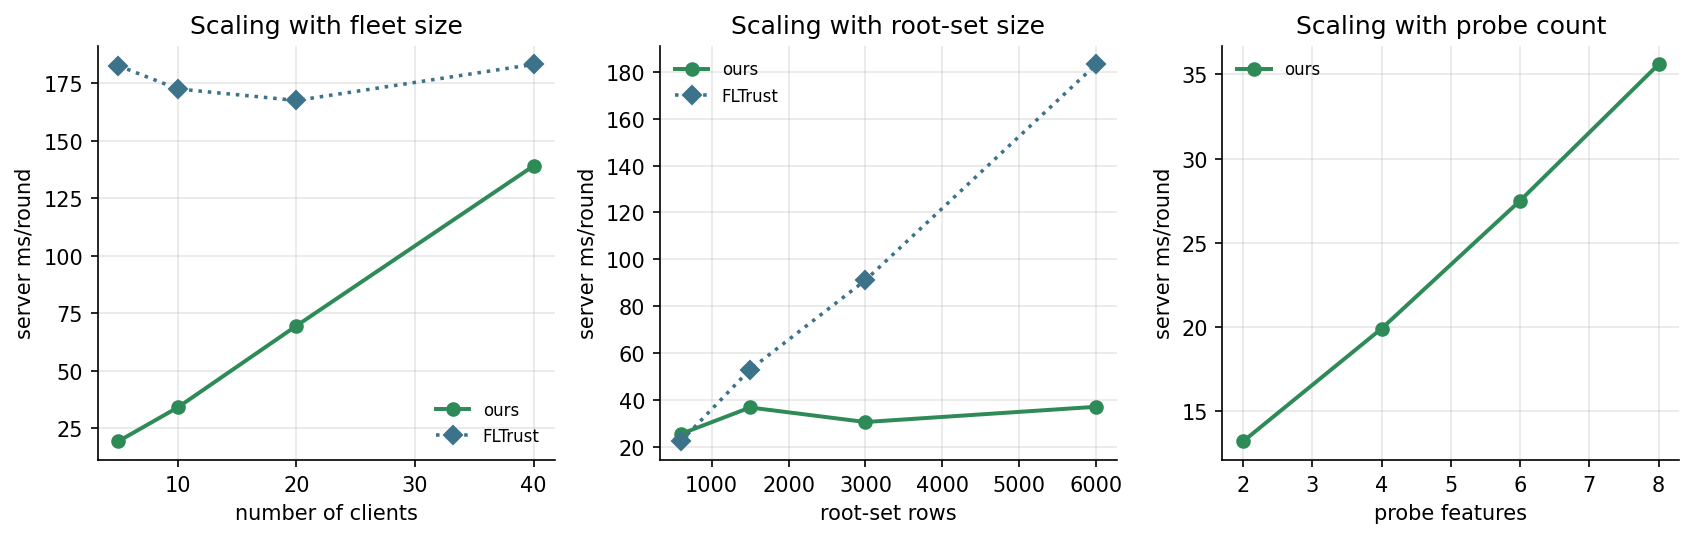

In [17]:
show('overhead_analysis.csv', caption='Both denominators')
show('overhead_scaling.csv', caption='Scaling in clients, root-set size and probe count')
fig('fig_overhead.png', width=900)

We withdraw the 1.1% figure. On a parallel round, bounded by the slowest client rather than
the sum of all clients, the same measurement is **3.40%**.

We also withdraw the large-fleet scalability claim, because the measurement contradicts it:
server cost is linear in the number of clients while a parallel round is roughly constant,
so the overhead *fraction* climbs from 5.6% at five clients to **34.9% at forty**. A large
fleet would need the probe subsampled or batched across rounds; neither is tested and
neither is claimed.

FLTrust on the same basis costs 168.3 ms/round (16.9% of a parallel round), roughly five
times ours, because it trains a server model every round.

---
## 6. Why the method is still needed — an unknown attacker count

Section 1 showed Multi-Krum matching us under IID. That comparison gives it an advantage a
deployment cannot: it is *told* how many clients are compromised. Trimmed mean and Krum
need the same input; our method has no such parameter.

Here the true attacker count varies from 1 to 4 while the Byzantine-robust rules stay
configured for `assumed_f = 2`, which is what a coordinator would have to guess.

In [18]:
run('exp_attacker_count.py')

[skipped] exp_attacker_count.py - set RUN_EXPERIMENTS = True to execute


**Backdoor lift as the true attacker count varies (baselines fixed at f=2)**

,True attackers,Method,Spoofing Recall,BSR,Backdoor Lift,Attacker Detect,Honest False-Flag
0,1,Coordinate-wise median,0.5196 +/- 0.0139,0.6642 +/- 0.0197,+0.0275 +/- 0.0056,---,---
1,1,Trimmed mean (f=2),0.5112 +/- 0.0124,0.6746 +/- 0.0104,+0.0380 +/- 0.0038,---,---
2,1,Krum (f=2),0.5289 +/- 0.0112,0.6582 +/- 0.0240,+0.0215 +/- 0.0164,100.0%,---
3,1,Multi-Krum (f=2),0.5325 +/- 0.0107,0.6372 +/- 0.0120,+0.0005 +/- 0.0068,100.0%,---
4,1,FLTrust,0.4796 +/- 0.0185,0.6993 +/- 0.0106,+0.0626 +/- 0.0153,91.7%,0.0%
5,1,Trust + median (ours),0.5409 +/- 0.0093,0.6225 +/- 0.0231,-0.0142 +/- 0.0098,100.0%,3.1%
6,2,Coordinate-wise median,0.5008 +/- 0.0133,0.7013 +/- 0.0072,+0.0646 +/- 0.0074,---,---
7,2,Trimmed mean (f=2),0.4808 +/- 0.0121,0.7154 +/- 0.0099,+0.0787 +/- 0.0065,---,---
8,2,Krum (f=2),0.5168 +/- 0.0116,0.6698 +/- 0.0165,+0.0331 +/- 0.0035,100.0%,---
9,2,Multi-Krum (f=2),0.5282 +/- 0.0165,0.6428 +/- 0.0102,+0.0061 +/- 0.0041,100.0%,---


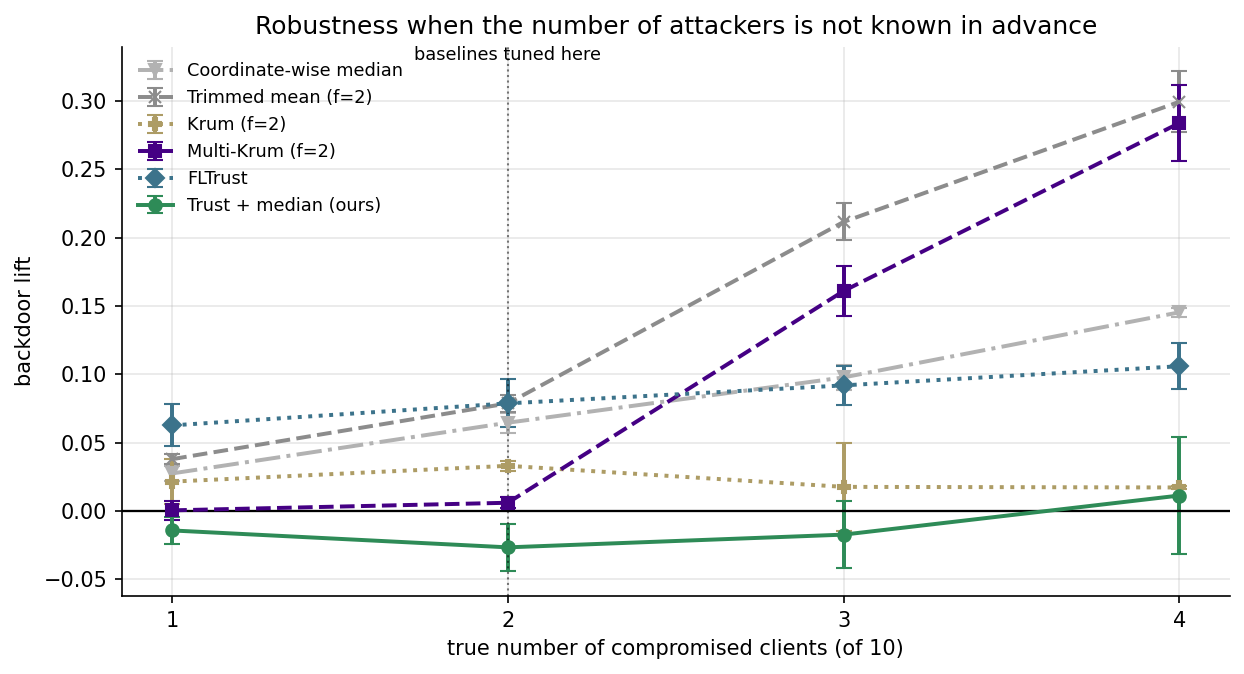

In [19]:
show('attacker_count.csv',
     ['True attackers', 'Method', 'Spoofing Recall', 'BSR', 'Backdoor Lift',
      'Attacker Detect', 'Honest False-Flag'],
     'Backdoor lift as the true attacker count varies (baselines fixed at f=2)')
fig('fig_attacker_count.png', width=760)

| True attackers | 1 | 2 | 3 | 4 |
|---|---|---|---|---|
| Multi-Krum (told 2) | +0.0005 | +0.0061 | +0.1609 | **+0.2837** |
| Trimmed mean (told 2) | +0.0380 | +0.0787 | +0.2114 | **+0.2992** |
| **Ours (no such setting)** | −0.0142 | −0.0265 | −0.0172 | **+0.0114** |

Multi-Krum matched us only at the count it was tuned for. At four attackers it is back
near undefended FedAvg (+0.2415), while ours holds.

**One baseline resists this and we report it:** single-Krum stays between +0.0172 and
+0.0331 throughout, because selecting the single most central update is insensitive to how
many outliers surround it. Its cost is discarding nine of ten client updates every round,
and like the other geometric rules it yields a selection rather than a per-client judgment,
so it cannot report *which* aircraft is compromised.

---
## 7. Comment 7 — Softened claims

Applied verbatim in the abstract, results, discussion and conclusion. Verified by grepping
the LaTeX source for each original phrase and confirming zero matches.

| Was | Now |
|---|---|
| "eliminates the attacker's advantage" | "reduces attack-induced backdoor lift to a level statistically indistinguishable from the honest baseline" |
| "survives a defense-aware adaptive attacker" | "remains effective against the tested defense-aware evasion objective" |
| "each layer alone is insufficient" | "behavioral trust provides most of the measured protection, while coordinate-wise median is retained as a robust backstop" |
| "a stronger detector would not change the defense conclusions" | "additional evaluation is needed to determine whether the findings transfer to stronger detector architectures" |

Two further instances were found on a second pass that the first had missed: a
contributions bullet still read *"the defense eliminates the attacker's advantage ... and
roughly 1.1% server-side overhead"*, and the methodology section still read *"each layer
alone is insufficient"*. Both are fixed.

---
## 8. Reproducing everything

```bash
cd weeks/week12-paper
python run_all.py --list     # stages and approximate runtimes
python run_all.py            # everything (several hours on CPU)
python run_all.py noniid     # one stage
```

Or set `RUN_EXPERIMENTS = True` in Section 0 of this notebook and run it top to bottom.

Every stage re-derives the data split from the fixed seed 42, so stages are independent and
can run in any order. Each writes to `results/*.csv`; the paper's tables are transcribed
from those files, never from a console log. Runs are deterministic on a given machine,
which we verified by executing the FLTrust benchmark twice and getting bit-identical
output.

In [20]:
import subprocess, sys
print(subprocess.run([sys.executable, 'run_all.py', '--list'],
                     capture_output=True, text=True, cwd=HERE).stdout)
print('exported result files:')
for f in sorted(RES.glob('*.csv')):
    print(f'  {f.name:<38} {f.stat().st_size:>7,} bytes')

stage       script                          approx   what it produces
dataset     dataset_characterization.py     ~1 min   Table: per-feature Cohen's d and the probe set
detector    exp_detector.py                 ~5 min   Table+fig: centralised detector ceiling (reviewer comment 4)
baselines   exp_baselines.py                ~20 min  Table+fig: all nine aggregation rules (comments 1, 5)
fltrust     fltrust_benchmark.py            ~10 min  Table+fig: focused FLTrust head-to-head (comment 1)
noniid      exp_noniid.py                   ~45 min  Table+fig: Dirichlet non-IID sweep (comment 2)
median      exp_median_stress.py            ~30 min  Table+fig: is the median layer necessary (comment 3)
attackers   exp_attacker_count.py           ~25 min  Table+fig: robustness when f is unknown (comments 1, 5)
overhead    exp_overhead.py                 ~10 min  Table+fig: overhead recomputed, parallel + scaling (comment 6)
strong      exp_strong_detector.py          ~50 min  Table+fig: do conclu

---
## 9. What the revision changed, in summary

**Stronger than before**

- Nine aggregation rules compared on one pipeline, including every baseline the review named.
- Every number traceable to an exported CSV; one command reproduces all of them.
- Full operating point reported, not accuracy alone.
- We found our own most important weakness before a reviewer did.

**Honestly weaker than we thought**

- The headline result is scoped to fleets with roughly even data. Under skew, which is the
  realistic case, the trust layer stops firing.
- Multi-Krum matches us under IID at a fraction of the cost. Our advantage rests on not
  needing the attacker count, and on naming the culprits.
- The detector is weak, and that is our federated configuration rather than the dataset.

**Next steps, in priority order**

1. A per-client suspicion statistic instead of one normalised against the cohort. Direct fix
   for the skew failure; the harness already supports testing it.
2. Train the federated detector properly (30 rounds, 256-128-64 reaches 0.851 recall).
3. A second, independent signal domain. Everything here is one dataset.